## Trade composition and employment: 
Is the weight of manufactured goods in a country's trade associated with different unemployment levels?

In [ ]:
import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style= "whitegrid")

conn = sqlite3.connect(Path.cwd().parent/"database/ue_market.db")
pd.read_sql("SELECT name FROM sqlite_master WHERE   type= 'table'", conn)

,name
0,trade_category
1,trade_total
2,unemployment_ue
3,data_breaks_ue
4,gdp_ue


In [ ]:
manufactured_df= pd.read_sql("""
WITH CTE_ranked AS (
    SELECT 
        country_code,
        product_code,
        product_description,
        SUM(value_meur) AS total_export_for_product
    FROM trade_category
    WHERE indic_et = 'export'
        AND year >= 2016
    GROUP BY country_code, product_code, product_description
),
CTE_AVG_unemployment_rate AS (
    SELECT
        country_code,
        country,
        AVG(unemployment_rate) AS AVG_unemployment_rate
    FROM unemployment_ue
    GROUP BY country_code, country
),
CTE_trade_total AS (
    SELECT 
        country_code,
        SUM(value_meur) AS total_exports
    FROM trade_total
    WHERE indic_et = 'export'
        AND year >= 2016
    GROUP BY country_code
)
	
SELECT
    a.country_code,
    b.country,
    MAX(CASE WHEN a.product_code = 'SITC5' THEN a.product_description END) AS chemicals_product,
    ROUND(CAST(MAX(CASE WHEN a.product_code = 'SITC5' THEN a.total_export_for_product END) AS FLOAT) / MAX(c.total_exports) * 100, 1) AS chemicals_product_percentage,
    MAX(CASE WHEN a.product_code = 'SITC6_8' THEN a.product_description END) AS other_manufactured_product,
    ROUND(CAST(MAX(CASE WHEN a.product_code = 'SITC6_8' THEN a.total_export_for_product END) AS FLOAT) / MAX(c.total_exports) * 100, 1) AS other_manufactured_product_percentage,
    MAX(CASE WHEN a.product_code = 'SITC7' THEN a.product_description END) AS machinery_transport_product,
    ROUND(CAST(MAX(CASE WHEN a.product_code = 'SITC7' THEN a.total_export_for_product END) AS FLOAT) / MAX(c.total_exports) * 100, 1) AS machinery_transport_product_percentage,
    ROUND(CAST(
        SUM(CASE WHEN a.product_code IN ('SITC5', 'SITC6_8', 'SITC7') THEN a.total_export_for_product END) AS FLOAT) / MAX(c.total_exports) * 100, 1) AS total_manufactured_percentage,     
    ROUND(MAX(b.AVG_unemployment_rate), 2) AS AVG_unemployment_rate
FROM CTE_ranked a
JOIN CTE_AVG_unemployment_rate b ON a.country_code = b.country_code
JOIN CTE_trade_total c ON a.country_code = c.country_code
GROUP BY a.country_code, b.country
ORDER BY AVG_unemployment_rate DESC""",
conn)

In [ ]:
manufactured_df

,country_code,country,chemicals_product,chemicals_product_percentage,other_manufactured_product,other_manufactured_product_percentage,machinery_transport_product,machinery_transport_product_percentage,total_manufactured_percentage,AVG_unemployment_rate
0,EL,Greece,chemicals,12.2,other_manufactured,22.9,machinery_transport,9.6,44.7,15.82
1,ES,Spain,chemicals,15.2,other_manufactured,25.4,machinery_transport,30.6,71.1,14.37
2,IT,Italy,chemicals,15.2,other_manufactured,34.4,machinery_transport,34.1,83.7,9.07
3,FR,France,chemicals,19.6,other_manufactured,23.3,machinery_transport,36.1,79.0,8.25
4,FI,Finland,chemicals,10.5,other_manufactured,34.2,machinery_transport,31.8,76.5,7.94
5,SE,Sweden,chemicals,13.8,other_manufactured,25.5,machinery_transport,39.2,78.5,7.71
6,HR,Croatia,chemicals,12.5,other_manufactured,29.9,machinery_transport,23.5,65.9,7.67
7,CY,Cyprus,chemicals,13.2,other_manufactured,4.8,machinery_transport,37.7,55.8,7.58
8,LV,Latvia,chemicals,9.8,other_manufactured,27.3,machinery_transport,21.6,58.7,7.50
9,PT,Portugal,chemicals,10.0,other_manufactured,38.0,machinery_transport,28.1,76.0,7.35


After extracting the data needed to answer the second question, we calculate the correlation between unemployment and the weight of manufactured goods for a given European nation.

In [ ]:
manufactured_df["total_manufactured_percentage"].corr(manufactured_df["AVG_unemployment_rate"])


np.float64(-0.5967556955317173)

Additionally, I employ the Spearman rank correlation coefficient to assess whether extreme outliers might heavily influence the relationship between manufactured exports and unemployment rates.

In [ ]:
manufactured_df["total_manufactured_percentage"].corr(manufactured_df["AVG_unemployment_rate"], method="spearman")


np.float64(-0.48229548229548225)

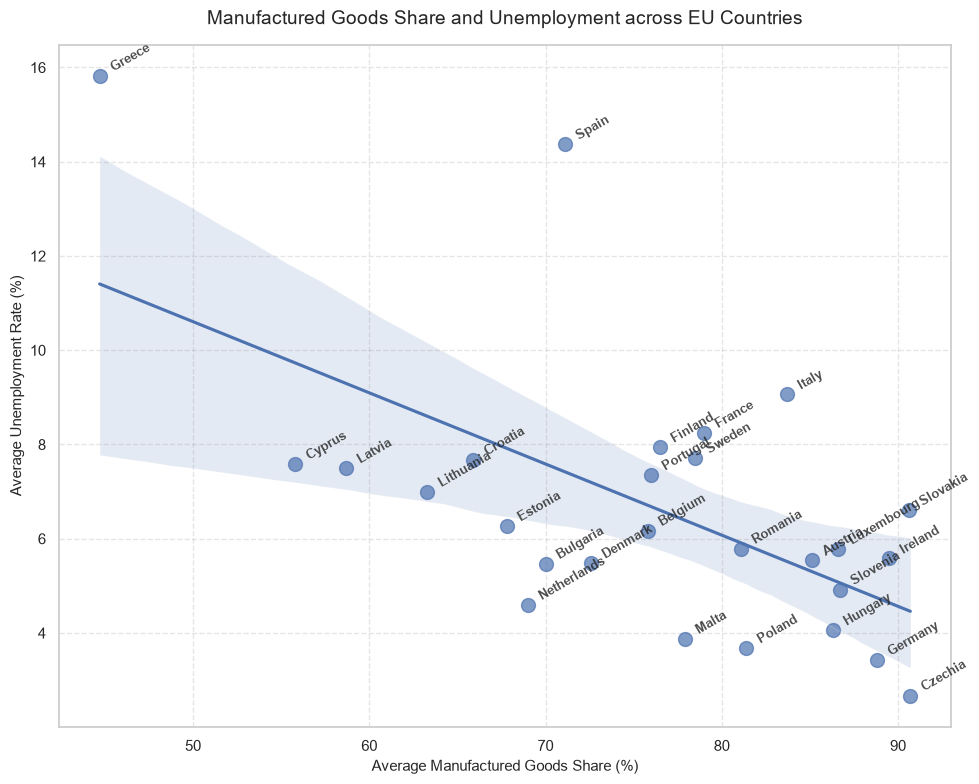

In [ ]:
df_plot = manufactured_df.reset_index()
plt.figure(figsize=(10, 8))
sns.regplot(
    data=df_plot,
    x="total_manufactured_percentage",
    y="AVG_unemployment_rate",
    color="#4c72b0",
    scatter_kws={"s": 100, "alpha": 0.7}
)

for index, row in df_plot.iterrows():
    plt.text(
        x=row["total_manufactured_percentage"] + 0.5,      
        y=row["AVG_unemployment_rate"] + 0.1, 
        s=row["country"],
        fontsize=9,
        weight="bold",
        alpha=0.8,
        rotation=30
    )

plt.title("Manufactured Goods Share and Unemployment across EU Countries", fontsize=14, pad=15)
plt.xlabel("Average Manufactured Goods Share (%)", fontsize=11)
plt.ylabel("Average Unemployment Rate (%)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(Path.cwd().parent/"data/charts/manufactured_goods_unemployment.png", dpi=300, bbox_inches="tight")
plt.show()

I also want to see the correlation between the openess of a country and its weight of manufactured goods. <br>
If the correlation is low, We can infer that the two variables are weakly linked.

In [ ]:
df_openness= pd.read_sql(""" 
 WITH CTE_trade_base AS (
    SELECT a.country_code, a.country, a.year, a.gdp_meur,
           b.unemployment_rate, c.value_meur AS trade_value, c.indic_et
    FROM gdp_ue a
    JOIN unemployment_ue b ON a.country_code = b.country_code AND a.year = b.year
    JOIN trade_total c ON a.country_code = c.country_code AND a.year = c.year
    WHERE a.unit = 'nominal' AND c.indic_et IN ('export', 'import')
),
CTE_pivoted AS (
    SELECT country, year, gdp_meur, unemployment_rate,
           MAX(CASE WHEN indic_et = 'export' THEN trade_value END) AS export,
           MAX(CASE WHEN indic_et = 'import' THEN trade_value END) AS import
    FROM CTE_trade_base
    GROUP BY country, year, gdp_meur, unemployment_rate
),
CTE_country_avg AS (
    SELECT country,
           ROUND(AVG((export + import) / gdp_meur * 100), 2) AS avg_openness,
           ROUND(AVG(unemployment_rate), 2) AS avg_unemployment
    FROM CTE_pivoted
    GROUP BY country
)
SELECT
    country,
    avg_openness,
    avg_unemployment,
    CASE 
        WHEN buckets = 1 THEN 'low'
        WHEN buckets = 2 THEN 'medium'
        WHEN buckets = 3 THEN 'high'
    END AS openness_level
FROM (
    SELECT
        country,
        avg_openness,
        avg_unemployment,
        NTILE(3) OVER (ORDER BY avg_openness) AS buckets
    FROM CTE_country_avg
) sub
ORDER BY avg_openness DESC
""", conn)

In [ ]:
df_check = manufactured_df.merge(df_openness, on="country")
df_check["total_manufactured_percentage"].corr(df_check["avg_openness"])

np.float64(0.22455273275800275)

### Conclusions for trade composition and unemployment rate 

The share of manufactured goods (chemicals, other_manufactured, machinery_transport) in a country's exports shows a moderate-to-strong negative correlation with unemployment (Pearson r = -0.60): countries whose exports are more manufacturing-oriented tend to have lower unemployment. This link is stronger than the one found for trade openness in Question 1 (r = -0.42), suggesting that what a country exports matters more for employment than how much it trades. <br>
The correlation is robust to the choice of method: Pearson r = -0.60 and Spearman ρ = -0.48. The lower Spearman value indicates that outliers (Greece and Spain) somewhat strengthen the linear correlation, but the negative relationship holds even under the rank-based, outlier-robust measure. <br>
Crucially, manufacturing share and trade openness are only weakly correlated with each other (r = +0.22), meaning they capture two largely independent dimensions — the composition effect is not simply a restatement of the volume effect. <br>
Both metrics are computed over the same 2016-2025 period, consistent with Question 1. As there, the relationship is dispersed and should be read with caution: Greece and Spain are clear outliers with low manufacturing share and very high unemployment. Moreover, correlation does not imply causation — both high manufacturing intensity and low unemployment may stem from a common underlying factor, such as the industrial economic model of Central-Eastern European countries, rather than one causing the other. The temporal dynamics and shock responses are examined separately in Question 3.